# Regresión Lineal Multivariable, Regresión Polinómica y Ecuación Normal
### Dataset: Insurance Company Benchmark (COIL 2000)




In [1]:
# utilizado para manejos de directorios y rutas
import os

# Computacion vectorial y cientifica para python
import numpy as np

# Librerias para graficación (trazado de gráficos)
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para graficar superficies 3D

# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline

## 1 Carga y exploración del dataset


In [2]:
# Cargar datos
data = np.loadtxt('ticdata2000.txt', delimiter='\t')

X = data[:, 0:15]
y = data[:, -1]
m = y.size

print('Numero de ejemplos (m):', m)
print('Numero de caracteristicas (n):', X.shape[1])

# imprimir algunos puntos de datos (primeras 5 columnas y la etiqueta)
print('{:>6s}{:>6s}{:>6s}{:>6s}{:>6s}{:>10s}'.format('X0', 'X1', 'X2', 'X3', 'X4', 'CARAVAN'))
print('-'*40)
for i in range(10):
    print('{:6.0f}{:6.0f}{:6.0f}{:6.0f}{:6.0f}{:10.0f}'.format(X[i,0], X[i,1], X[i,2], X[i,3], X[i,4], y[i]))

Numero de ejemplos (m): 5822
Numero de caracteristicas (n): 15
    X0    X1    X2    X3    X4   CARAVAN
----------------------------------------
    33     1     3     2     8         0
    37     1     2     2     8         0
    37     1     2     2     8         0
     9     1     3     3     3         0
    40     1     4     2    10         0
    23     1     2     1     5         0
    39     2     3     2     9         0
    33     1     2     3     8         0
    33     1     2     4     8         0
    11     2     3     3     3         0


## 2 División en conjunto de entrenamiento y validación


In [3]:
np.random.seed(42)
indices = np.random.permutation(m)
train_size = int(0.8 * m)
train_idx, test_idx = indices[:train_size], indices[train_size:]

X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]
m_train = y_train.size
m_test = y_test.size

print('Ejemplos de entrenamiento:', m_train)
print('Ejemplos de validacion:', m_test)

Ejemplos de entrenamiento: 4657
Ejemplos de validacion: 1165


## 3 Relación entre una característica y la etiqueta

Antes de entrenar se grafica una de las características contra la etiqueta, para verificar que exista algún tipo de relación.

Coeficiente de correlacion entre X3 y y: 0.003974527850251161


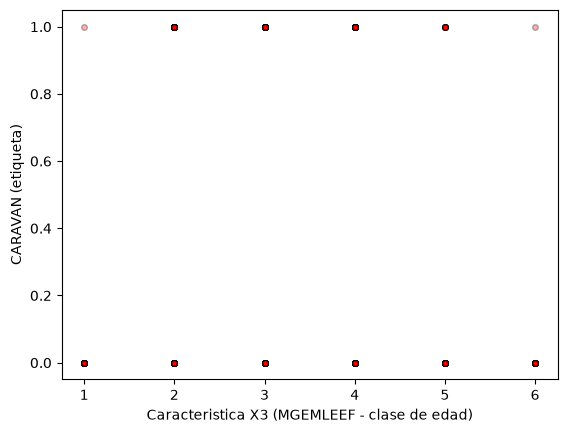

In [4]:
def plotData(x, y):
    # Grafica los puntos x e y en una figura nueva.
    fig = pyplot.figure()
    pyplot.plot(x, y, 'ro', ms=4, mec='k', alpha=0.3)
    pyplot.ylabel('CARAVAN (etiqueta)')
    pyplot.xlabel('Caracteristica X3 (MGEMLEEF - clase de edad)')

plotData(X_train[:, 3], y_train)
print('Coeficiente de correlacion entre X3 y y:', np.corrcoef(X_train[:, 3], y_train)[0, 1])

## 4 Funciones comunes


In [5]:
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1  # evita division por cero en columnas constantes

    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma


def computeCostMulti(X, y, theta):
    m = y.shape[0]
    J = (1 / (2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J


def gradientDescentMulti(X, y, theta, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

## 5 Modelo 1: Regresión lineal multivariable (descenso por el gradiente)

Se utilizan las 15 caracteristicas seleccionadas directamente (sin elevarlas al cuadrado ni combinarlas).

In [6]:
# Normalizacion de caracteristicas (con la media y desviacion del set de entrenamiento)
X_train_norm, mu, sigma = featureNormalize(X_train)
X_test_norm = (X_test - mu) / sigma

# Añade el termino de interseccion (columna de unos para theta0)
X_train_multi = np.concatenate([np.ones((m_train, 1)), X_train_norm], axis=1)
X_test_multi = np.concatenate([np.ones((m_test, 1)), X_test_norm], axis=1)

#### 5.1 Seleccionando el coheficiente de aprendizaje

theta calculado por el descenso por el gradiente: [ 0.06076874  0.01166476 -0.00307257 -0.00285807  0.00217878 -0.02714502
 -0.0030688  -0.00174363  0.00075581 -0.00887389  0.01827114  0.00305952
  0.00176937 -0.01682738 -0.01601924 -0.01463072]
Costo final de entrenamiento: 0.02822843379065195


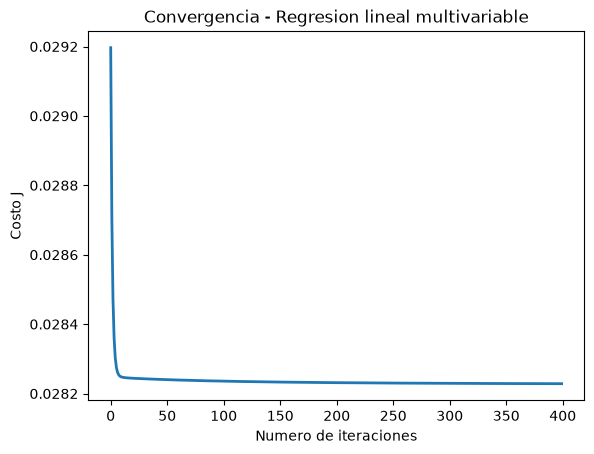

In [7]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.3
num_iters = 400

theta_multi = np.zeros(X_train_multi.shape[1])
theta_multi, J_history_multi = gradientDescentMulti(X_train_multi, y_train, theta_multi, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history_multi)), J_history_multi, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia - Regresion lineal multivariable')

print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta_multi)))
print('Costo final de entrenamiento:', J_history_multi[-1])

### Predicciones y validación del modelo multivariable

Se generan las predicciones sobre el conjunto de validación (203 ejemplos que el modelo no vio durante el entrenamiento) y se calcula el error.

In [8]:
pred_multi = np.dot(X_test_multi, theta_multi)

print('Primeras 100 predicciones (Modelo lineal multivariable) sobre el conjunto de validacion:')
print('{:>6s}{:>12s}{:>10s}'.format('Idx', 'Prediccion', 'Real'))
print('-'*30)
for i in range(100):
    print('{:6d}{:12.4f}{:10.0f}'.format(i, pred_multi[i], y_test[i]))

costo_val_multi = computeCostMulti(X_test_multi, y_test, theta_multi)
mae_multi = np.mean(np.abs(pred_multi - y_test))
acc_multi = np.mean(np.round(np.clip(pred_multi, 0, 1)) == y_test)

print('\nCosto J sobre validacion:', costo_val_multi)
print('Error absoluto medio (MAE) sobre validacion:', mae_multi)
print('Exactitud redondeando la prediccion a 0/1:', acc_multi)

Primeras 100 predicciones (Modelo lineal multivariable) sobre el conjunto de validacion:
   Idx  Prediccion      Real
------------------------------
     0      0.0272         0
     1      0.0587         0
     2      0.0883         0
     3      0.0266         0
     4      0.0581         0
     5      0.0352         0
     6      0.0643         0
     7      0.0635         0
     8      0.0523         0
     9      0.0352         0
    10      0.0340         0
    11      0.0939         0
    12      0.0573         0
    13      0.0514         0
    14      0.0231         0
    15      0.0383         0
    16      0.0742         0
    17      0.0828         0
    18      0.0522         0
    19      0.0434         0
    20      0.0489         0
    21      0.0365         0
    22      0.0529         0
    23      0.0654         0
    24      0.0532         0
    25      0.0421         0
    26      0.1020         0
    27      0.0469         0
    28      0.0489         0
    29    

## 6 Modelo 2: Regresión polinómica (descenso por el gradiente)

Se toma una unica caracteristica (X3, clase de edad) y se agrega su termino cuadratico, de forma analoga a como se hizo con la regresion multivariable pero ahora con $x$ y $x^2$ como las dos columnas de entrada.

In [9]:
x_train_1 = X_train[:, 3:4]
x_test_1 = X_test[:, 3:4]

X_train_poly = np.concatenate([x_train_1, x_train_1 ** 2], axis=1)
X_test_poly = np.concatenate([x_test_1, x_test_1 ** 2], axis=1)

# Normalizacion (misma mu/sigma del set de entrenamiento)
X_train_poly_norm, mu_poly, sigma_poly = featureNormalize(X_train_poly)
X_test_poly_norm = (X_test_poly - mu_poly) / sigma_poly

X_train_poly_norm = np.concatenate([np.ones((m_train, 1)), X_train_poly_norm], axis=1)
X_test_poly_norm = np.concatenate([np.ones((m_test, 1)), X_test_poly_norm], axis=1)

theta calculado (polinomico): [ 0.06076874  0.01705369 -0.01645262]
Costo final de entrenamiento: 0.028531231904498265


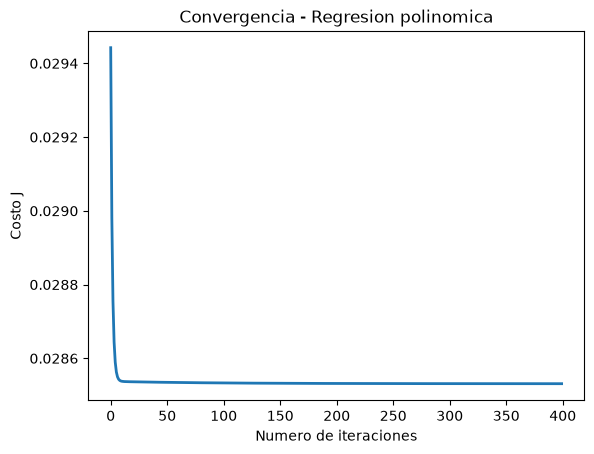

In [10]:
alpha_poly = 0.3
num_iters_poly = 400

theta_poly = np.zeros(X_train_poly_norm.shape[1])
theta_poly, J_history_poly = gradientDescentMulti(X_train_poly_norm, y_train, theta_poly, alpha_poly, num_iters_poly)

pyplot.plot(np.arange(len(J_history_poly)), J_history_poly, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia - Regresion polinomica')

print('theta calculado (polinomico): {:s}'.format(str(theta_poly)))
print('Costo final de entrenamiento:', J_history_poly[-1])

### Predicciones y validación del modelo polinómico

In [11]:
pred_poly = np.dot(X_test_poly_norm, theta_poly)

print('Primeras 100 predicciones (Modelo polinomico) sobre el conjunto de validacion:')
print('{:>6s}{:>12s}{:>10s}'.format('Idx', 'Prediccion', 'Real'))
print('-'*30)
for i in range(100):
    print('{:6d}{:12.4f}{:10.0f}'.format(i, pred_poly[i], y_test[i]))

costo_val_poly = computeCostMulti(X_test_poly_norm, y_test, theta_poly)
mae_poly = np.mean(np.abs(pred_poly - y_test))

print('\nCosto J sobre validacion:', costo_val_poly)
print('Error absoluto medio (MAE) sobre validacion:', mae_poly)

Primeras 100 predicciones (Modelo polinomico) sobre el conjunto de validacion:
   Idx  Prediccion      Real
------------------------------
     0      0.0620         0
     1      0.0629         0
     2      0.0620         0
     3      0.0620         0
     4      0.0576         0
     5      0.0576         0
     6      0.0629         0
     7      0.0629         0
     8      0.0629         0
     9      0.0576         0
    10      0.0629         0
    11      0.0620         0
    12      0.0629         0
    13      0.0629         0
    14      0.0629         0
    15      0.0576         0
    16      0.0629         0
    17      0.0629         0
    18      0.0629         0
    19      0.0629         0
    20      0.0629         0
    21      0.0576         0
    22      0.0550         0
    23      0.0576         0
    24      0.0620         0
    25      0.0629         0
    26      0.0629         0
    27      0.0576         0
    28      0.0576         0
    29      0.0629  

## 7 Modelo 3: Ecuación de la Normal


In [12]:
def normalEqn(X, y):
    theta = np.zeros(X.shape[1])
    theta = np.dot(np.dot(np.linalg.pinv(np.dot(X.T, X)), X.T), y)
    return theta

X_train_normal = np.concatenate([np.ones((m_train, 1)), X_train], axis=1)
X_test_normal = np.concatenate([np.ones((m_test, 1)), X_test], axis=1)

theta_normal = normalEqn(X_train_normal, y_train)

print('Theta calculado a partir de la ecuacion de la normal: {:s}'.format(str(theta_normal)))
print('Costo J sobre entrenamiento:', computeCostMulti(X_train_normal, y_train, theta_normal))

Theta calculado a partir de la ecuacion de la normal: [ 0.14580809  0.0022031  -0.00814599 -0.00321249  0.00273165 -0.01532157
 -0.00329915 -0.00116635  0.00061293 -0.00568057  0.01020315  0.00357011
  0.00149733 -0.0096959  -0.01028735 -0.00767832]
Costo J sobre entrenamiento: 0.028226616716682612


### Predicciones y validación con la ecuación de la normal

In [13]:
pred_normal = np.dot(X_test_normal, theta_normal)

print('Primeras 100 predicciones (Ecuacion de la normal) sobre el conjunto de validacion:')
print('{:>6s}{:>12s}{:>10s}'.format('Idx', 'Prediccion', 'Real'))
print('-'*30)
for i in range(100):
    print('{:6d}{:12.4f}{:10.0f}'.format(i, pred_normal[i], y_test[i]))

costo_val_normal = computeCostMulti(X_test_normal, y_test, theta_normal)
mae_normal = np.mean(np.abs(pred_normal - y_test))

print('\nCosto J sobre validacion:', costo_val_normal)
print('Error absoluto medio (MAE) sobre validacion:', mae_normal)

Primeras 100 predicciones (Ecuacion de la normal) sobre el conjunto de validacion:
   Idx  Prediccion      Real
------------------------------
     0      0.0258         0
     1      0.0591         0
     2      0.0888         0
     3      0.0250         0
     4      0.0566         0
     5      0.0333         0
     6      0.0677         0
     7      0.0635         0
     8      0.0505         0
     9      0.0333         0
    10      0.0312         0
    11      0.0963         0
    12      0.0563         0
    13      0.0517         0
    14      0.0204         0
    15      0.0404         0
    16      0.0736         0
    17      0.0812         0
    18      0.0524         0
    19      0.0457         0
    20      0.0464         0
    21      0.0369         0
    22      0.0565         0
    23      0.0653         0
    24      0.0529         0
    25      0.0446         0
    26      0.0992         0
    27      0.0506         0
    28      0.0468         0
    29      0.06

## 8 Comparación de los tres modelos

In [14]:
print('{:<35s}{:>15s}{:>15s}'.format('Modelo', 'Costo J (val)', 'MAE (val)'))
print('-'*65)
print('{:<35s}{:>15.6f}{:>15.6f}'.format('Lineal multivariable (GD)', costo_val_multi, mae_multi))
print('{:<35s}{:>15.6f}{:>15.6f}'.format('Polinomico (GD)', costo_val_poly, mae_poly))
print('{:<35s}{:>15.6f}{:>15.6f}'.format('Ecuacion de la normal', costo_val_normal, mae_normal))

Modelo                               Costo J (val)      MAE (val)
-----------------------------------------------------------------
Lineal multivariable (GD)                 0.025952       0.108849
Polinomico (GD)                           0.026347       0.109926
Ecuacion de la normal                     0.025937       0.108850
